![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

**Run only the first time you execute this Jupyter Notebook**
You can delete this command lines after succesfully installing this tools

In [ ]:
!sudo apt-get install libgomp1
!sudo apt-get install libxft2
!sudo apt-get install libglu1

[sudo] password for llopi: 
sudo: a password is required
^C
[sudo] password for llopi: 

Run everytime you start to execute this Jupyter Notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

## LO.1. Directional coupler cross-section in GDSFactory

### 1.1. Materials

In [5]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

### 1.2. Cross-Section Definition

In GDSFactory - Tidy3d modesolver we have another function to easily define the Cross-Section of a Directional Coupler: [gt.modes.WaveguideCoupler()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html). It implements the deep (rib) and shallow (ridge) directional coupler waveguides cross-section, using as input parameters all the dimensions of the waveguide cores and also the distance between them (gap). 

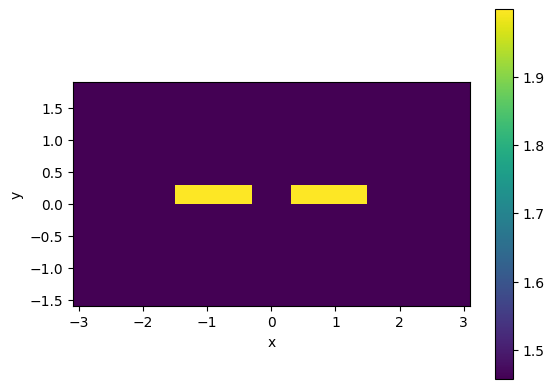

In [4]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_cs.plot_index()

### 1.3. Simulations

#### 1.3.1. Parameters

As before, we can calculate the effective index (n_eff), TE and TM fraction for this cross-section using the already implemented class methods: .n_eff, .fraction_te and .fraction_tm. Remember that we will calculate one effective index for each mode (up to num_modes)

In [5]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

2026-04-28 10:13:36.230 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_cbc1bb971a882eda.npz.


[1.60942484+1.02849974e-04j 1.60116589+9.83178135e-05j
 1.53540293+1.77367472e-04j 1.52057329+1.77190584e-04j]


In [6]:
dcoupler_cs.fraction_te

array([0.994898  , 0.99527537, 0.00888064, 0.01130183])

In [7]:
dcoupler_cs.fraction_tm

array([0.005102  , 0.00472463, 0.99111936, 0.98869817])

#### 1.3.2. Plots

We could also plot the fields for each mode identified. Remember: the 'Ex' field component corresponds to TE modes, while the 'Ey' field component corresponds to TM modes. In the case of the directional coupler, the even and odd modes play a key role in facilitating energy exchange between the waveguides. Now, let's plot and analyze their behavior.

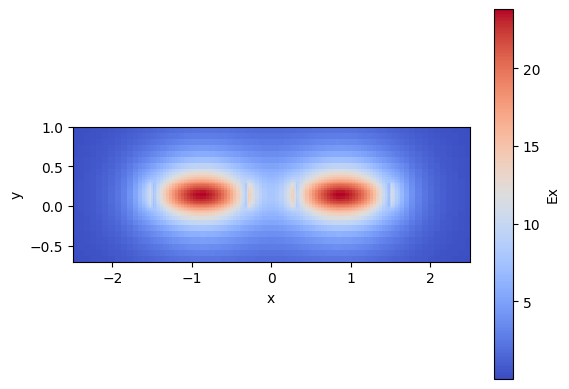

In [8]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

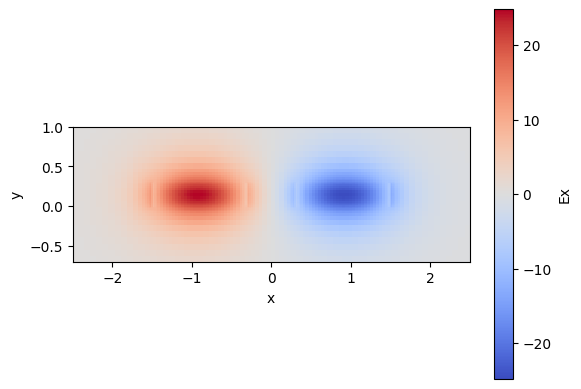

In [9]:
dcoupler_cs.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

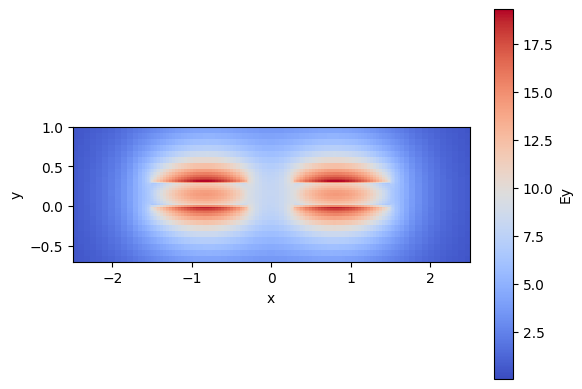

In [10]:
dcoupler_cs.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

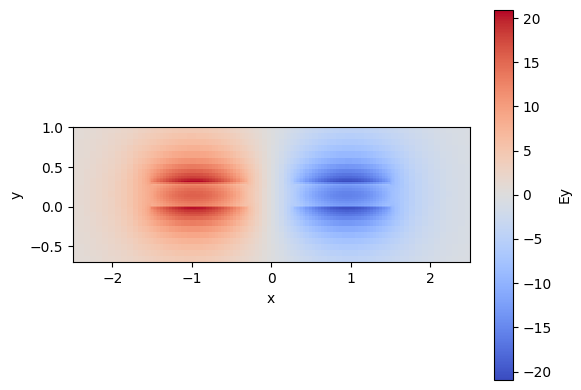

In [11]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-2.5, 2.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

#### 1.3.3. Beating or Coupling Length calculation (𝐿𝜋)

The key parameter that determines the design of a directional coupler is the coupling or beating length. This length defines the total size of the coupling region required to transfer all the optical power from one waveguide to another. It is determined by the difference between the effective indices of the cross-section's odd and even modes:

In [12]:
# TE Modes: Modes 0 & 1
L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(L_pi_TE)

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(L_pi_TM)

93.83767536699492
52.26022367744298


GDSFactory has its own method implemented to calculate the coupling length: [.coupling_length()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.WaveguideCoupler.html)

In [13]:
dcoupler_cs.coupling_length()

array([93.83767537, 52.26022368])

## LO.2. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of thickness 300 nm, 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

In [3]:
import math

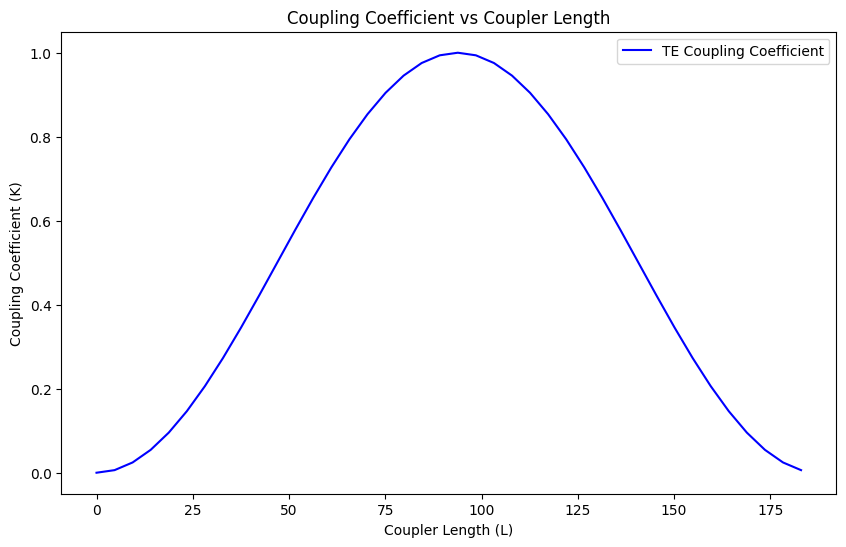

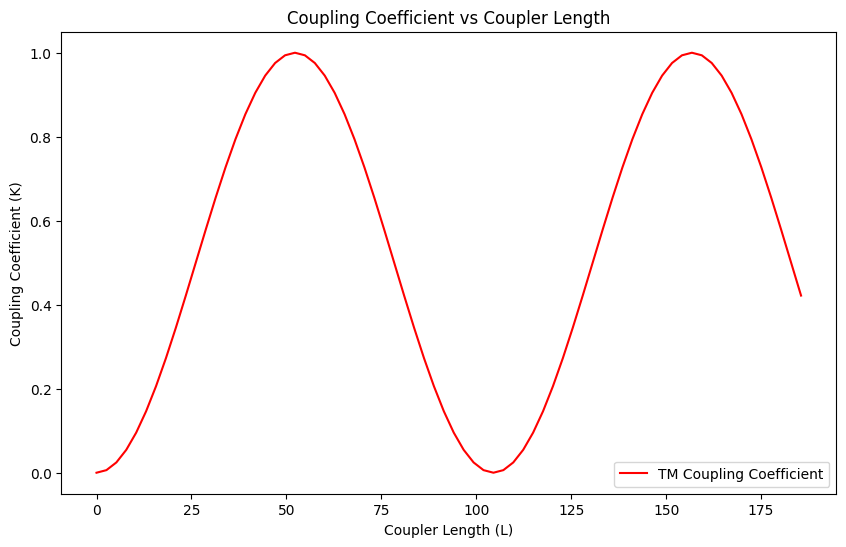

In [15]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)

L_TE = np.arange(0, 2*L_pi_TE, L_pi_TE/20)
L_TM = np.arange(0, 2*L_pi_TE, L_pi_TM/20)

# Calculamos el argumento dentro de la función seno
argumento_TE = 0.5 * np.pi * (L_TE / L_pi_TE)
# Calculamos el seno usando np.sin y lo elevamos al cuadrado
K_TE = (np.sin(argumento_TE))**2

# Calculamos el argumento dentro de la función seno
argumento_TM = 0.5 * np.pi * (L_TM / L_pi_TM)
# Calculamos el seno y lo elevamos al cuadrado
K_TM = (np.sin(argumento_TM))**2


plt.figure(1, figsize=(10, 6))
plt.plot(L_TE, K_TE, label='TE Coupling Coefficient', color='blue')
plt.xlabel('Coupler Length (L)')
plt.ylabel('Coupling Coefficient (K)')
plt.title('Coupling Coefficient vs Coupler Length')
plt.legend()
plt.figure(2, figsize=(10, 6))
plt.plot(L_TM, K_TM, label='TM Coupling Coefficient', color='red')
plt.xlabel('Coupler Length (L)')
plt.ylabel('Coupling Coefficient (K)')
plt.title('Coupling Coefficient vs Coupler Length')
plt.legend()

## LO.3. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 (50/50) directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [16]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 1 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2

m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  -318.88415207637405  µm


/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


In [17]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

ValueError: Number of samples, -3189, must be non-negative.

Now sweep gaps between 0.2 and 1.2 µm in steps of 0.2 µm

## LO.4. Parallel uncoupled waveguides

Parallel waveguides always exhibit some evanescent coupling. In this exercise, the goal is to control coupling so that adjacent waveguides remain effectively uncoupled. Define an uncoupled pair as one with coupling coefficient K < 0.01. Assume a parallel interaction length of L = 10 mm (typical chip length). For both shallow-etched and deep-etched waveguides, compute the minimum waveguide gap that satisfies this condition for the **TE0** mode, using w = 1.0 um and lambda = 1.55 um.



<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:56: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_117594/2599821015.py:46: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(gaps, l_pi_results, 'bo-', linewidth=2, label='$L_\pi$ medido')
/tmp/ipykernel_117594/2599821015.py:56: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("$L_\pi$ (um)", fontsize=12)
/tmp/ipykernel_117594/2599821015.py:57: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Longitud de Acoplamiento ($L_\pi$) vs Gap - Shallow Waveguide", fontsize=14)
/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the

Objetivo: L_pi > 156817.09 um
Simulando...
2026-05-03 23:38:40.076 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_cddc0f7926508e66.npz.
Gap: 4.50 um -> L_pi: 328831.66 um


/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-05-03 23:39:29.591 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_88b6fdea9bd5e3aa.npz.
Gap: 4.60 um -> L_pi: 1046.14 um


/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

...

2026-05-03 23:44:55.113 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_6bd53ceacac12e1b.npz.
Gap: 5.20 um -> L_pi: 1048.65 um


/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-05-03 23:45:39.478 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_f91723bdc659ed8b.npz.
Gap: 5.30 um -> L_pi: 375438.93 um


/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-05-03 23:46:43.196 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/WaveguideCoupler_3998d158313d2a02.npz.
Gap: 5.40 um -> L_pi: 1046.40 um


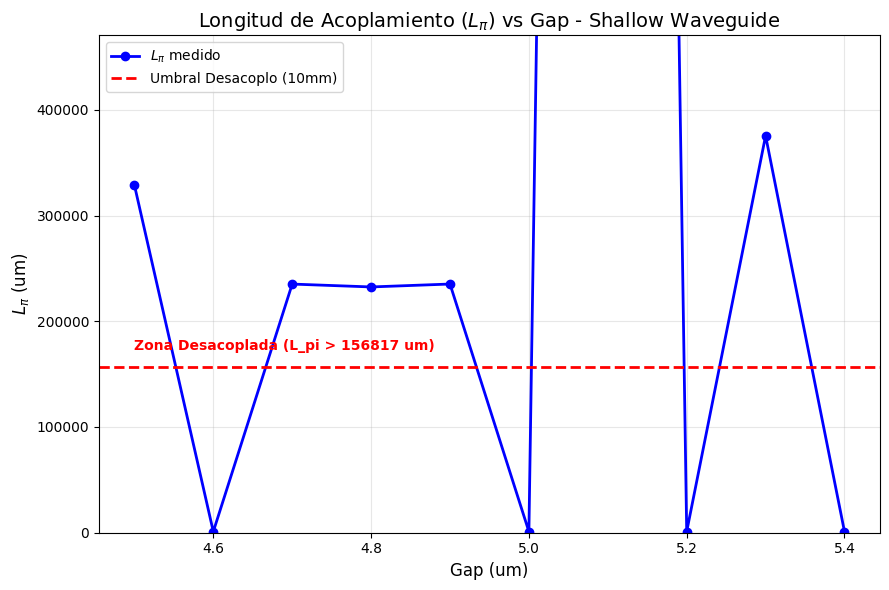


>>> RESULTADO: Necesitas probar gaps más grandes para llegar al umbral de 156 mm.


In [18]:
# --- Parámetros del problema ---
lambda_c = 1.55
L_chip = 10000  # 10 mm en micras
nm = 1e-3

# Cálculo del L_pi necesario para K < 0.01 en 10mm
# L_pi > (pi * L) / (2 * arcsin(sqrt(0.01)))
L_pi_threshold = (np.pi * L_chip) / (2 * np.arcsin(0.1)) 

# --- Configuración del Barrido ---
gaps = np.arange(4.5, 5.5, 0.1) 
l_pi_results = []

print(f"Objetivo: L_pi > {L_pi_threshold:.2f} um")
print("Simulando...")

for g in gaps:
    coupler = gt.modes.WaveguideCoupler(
        core_width=(1.0, 1.0), # Según enunciado LO.4
        slab_thickness=0 * nm, 
        core_thickness=300 * nm, 
        gap=g,
        core_material='sin',
        clad_material='sio2',
        wavelength=lambda_c,
        num_modes=2,
        cache_path='.cache/',
        precision='double',
        grid_resolution=20
    )
    
    # Diferencia de índices efectivos entre modo Simétrico y Antisimétrico
    dn = abs(coupler.n_eff[0].real - coupler.n_eff[1].real)
    
    # Evitar división por cero si dn es extremadamente pequeño
    if dn > 1e-9:
        lp = 0.5 * lambda_c / dn
    else:
        lp = 1e9 # Valor muy alto si están totalmente desacopladas
        
    l_pi_results.append(lp)
    print(f"Gap: {g:.2f} um -> L_pi: {lp:.2f} um")

# --- Gráfica Lineal ---
plt.figure(figsize=(9, 6))
plt.plot(gaps, l_pi_results, 'bo-', linewidth=2, label='$L_\pi$ medido')

# Línea del umbral para K=0.01
plt.axhline(L_pi_threshold, color='red', linestyle='--', linewidth=2, label='Umbral Desacoplo (10mm)')

# Anotación para claridad
plt.text(gaps[0], L_pi_threshold * 1.1, f'Zona Desacoplada (L_pi > {int(L_pi_threshold)} um)', 
         color='red', fontweight='bold')

plt.xlabel("Gap (um)", fontsize=12)
plt.ylabel("$L_\pi$ (um)", fontsize=12)
plt.title("Longitud de Acoplamiento ($L_\pi$) vs Gap - Shallow Waveguide", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Ajustar límites para ver bien el cruce
plt.ylim(0, L_pi_threshold * 3) # Zoom sobre la zona del umbral

plt.tight_layout()
plt.show()

# Conclusión por consola
if l_pi_results[-1] > L_pi_threshold:
    # Buscar el primer índice donde se supera el umbral
    idx = np.where(np.array(l_pi_results) > L_pi_threshold)[0][0]
    print(f"\n>>> RESULTADO: El gap mínimo para estar desacoplado es aprox {gaps[idx]:.2f} um.")
else:
    print("\n>>> RESULTADO: Necesitas probar gaps más grandes para llegar al umbral de 156 mm.")

## LO.5. Multimode Interference (MMI) Coupler cross-section

### LO.5.1. Cross-Section definition and simulation

In GDSFactory - Tidy3d modesolver, we can simulate the Cross-Section of a multimode interference coupler using the previously studied : [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. The parameters will correspond to the dimensions of the MMI body section. 

In [43]:
mmi_body_w = 12  
lambda_c = 1550*nm

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=20, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.n_eff

2026-04-28 18:52:15.843 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6c30818797bb0c38.npz.


array([1.6786595 +7.78934672e-05j, 1.67512732+7.81571827e-05j,
       1.66922847+7.86028340e-05j, 1.66094525+7.92401466e-05j,
       1.65025312+8.00839409e-05j, 1.63712124+8.11557006e-05j,
       1.6215135 +8.24863265e-05j, 1.60339058+8.41212350e-05j,
       1.58271457+8.61311110e-05j, 1.5774205 +1.66068730e-04j,
       1.57388942+1.66498915e-04j, 1.56799588+1.67223410e-04j,
       1.55972723+1.68258132e-04j, 1.5594584 +8.86366882e-05j,
       1.54906903+1.69617736e-04j, 1.53601168+1.71243999e-04j,
       1.53362692+9.19569893e-05j, 1.52054265+1.73463904e-04j,
       1.5053405 +9.64080926e-05j, 1.50269423+1.76086361e-04j])

In [44]:
mmi_body_waveguide.fraction_te

array([9.99991904e-01, 9.99967183e-01, 9.99924497e-01, 9.99861445e-01,
       9.99774272e-01, 9.99657368e-01, 9.99502382e-01, 9.99296461e-01,
       9.99013009e-01, 2.38565216e-04, 9.55099424e-04, 2.13831793e-03,
       3.73633926e-03, 9.98594348e-01, 5.78997522e-03, 9.32192912e-03,
       9.96954269e-01, 1.09103635e-02, 9.97247761e-01, 1.38536938e-02])

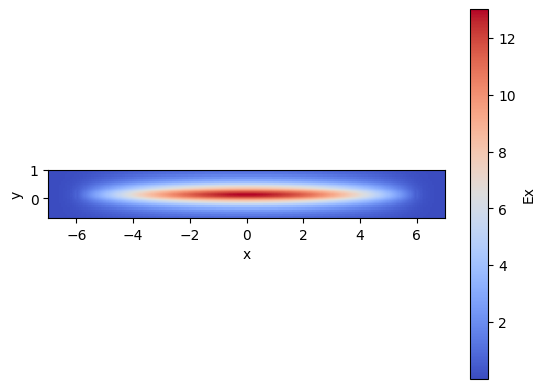

In [45]:
mmi_body_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 

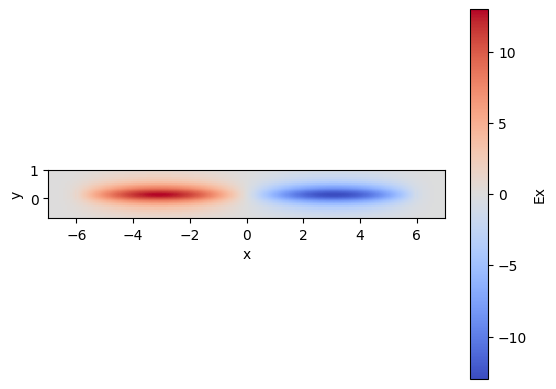

In [46]:
mmi_body_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

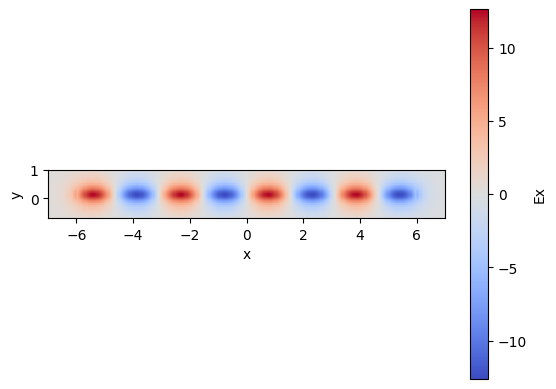

In [47]:
mmi_body_waveguide.plot_field(mode_index=7, # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-7, 7), # Set the x and y limits
                          ylim=(-0.7, 1)) #

#### LO.5.2 Length calculation (𝐿𝜋)

With this information, we could calculate our first guess for the 𝐿𝜋 length of the MMI coupler:

In [48]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

219.41119794418495


## LO.6. 2x2 Multimode Interference Coupler

### LO.6.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [9]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607255596  µm


/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


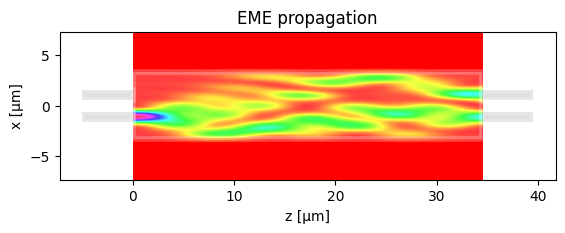

In [10]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.6.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/676 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.7300
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9524
Total OUT power: 0.8989
Excess loss [dB] =  0.4629
------------------------
Power over OUTs:  ['0.4495', '0.4494']
Ratio over OUTs ['0.5000', '0.5000']


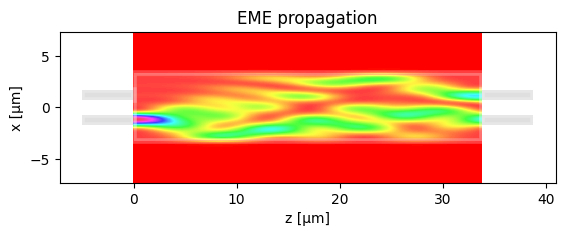

In [ ]:
dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.73  # STUDENT

# Run propagation
m.propagation()



### LO.6.3 2x2 Multimode Interference Coupler – Optimization (II)

In [6]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 0.75 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.0359860725655  µm


/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/692 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.1000
IO wg width 1.0000
IO wg width increment 0.7500
------------------------
Total power IN coupled 0.9926
Total OUT power: 0.9781
Excess loss [dB] =  0.0960
------------------------
Power over OUTs:  ['0.4963', '0.4819']
Ratio over OUTs ['0.5074', '0.4926']


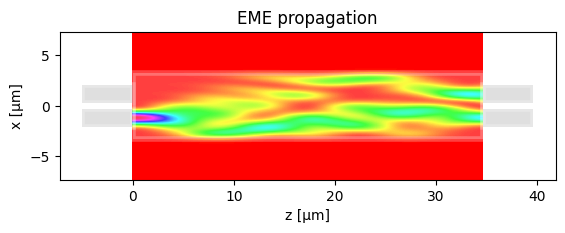

In [18]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = m.MMI_width*np.array([-1/6,1/6]) + np.array([-dy,dy]) # STUDENT
m.OUT_WVG_positions = m.MMI_width*np.array([-1/6,1/6]) + np.array([-dy,dy])  # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = 0.1 # STUDENT

# Run propagation
m.propagation()

anterior_1 = [0.4750, 0.4637, 6.3]
anterior_2 = [0.4764, 0.4595, 6.4]
anterior_3 = [0.4773, 0.4552, 6.5]
anterior_4 = [0.4756, 0.4384, 6.9]
anterior_5 = [0.4695, 0.4727, 6.1]  
anterior_6 = [0.4753, 0.4611, 6.35]
anterior_7 = [0.4756, 0.4683, 6.25]
anterior_8 = [0.4779, 0.4707, 0.25]
anterior_9 = [0.4897, 0.4682, 0.5]
anterior_10 = [0.4980, 0.4842, 0.8]
anterior_11 = [0.4995, 0.4909, 1]

## LO.7. 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

In [36]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 14   # MMI width
m.wg_width_dw = 0.75 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  296.1457695276486  µm


/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/1107 [00:00<?, ?it/s]

------- Pameters -------
MMI length 55.5273
MMI length increment -0.2000
IO wg width 1.0000
IO wg width increment 0.7500
------------------------
Total power IN coupled 0.9860
Total OUT power: 0.9313
Excess loss [dB] =  0.3090
------------------------
Power over OUTs:  ['0.2341', '0.2314', '0.2315', '0.2343']
Ratio over OUTs ['0.2514', '0.2485', '0.2485', '0.2516']


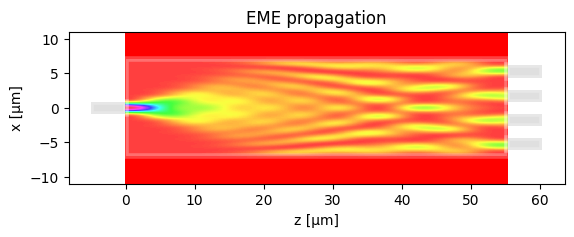

In [53]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 1 # STUDENT
m.n_OUT = 4 # STUDENT

dy = 0.1
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions =[0] # STUDENT
# MMI I/O waveguide positions (Calculadas para 1x4)
m.OUT_WVG_positions = m.MMI_width * np.array([-3/8, -1/8, 1/8, 3/8]) # STUDENT

# MMI length (check class slides for type of MMI)
# MMI length (Corregido para 1x4 Simétrico)
m.L_MMI = (3/16) * L_pi  # STUDENT (0.1875 * L_pi)
m.dL_MMI = -0.2 # STUDENT

# Run propagation
m.propagation()

## Extra - Exercises

### E1. Directional coupler gap dependence

In [21]:
gap_to_simulate = 1000 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=gap_to_simulate,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

deep_dcoupler_neff = deep_dcoupler_cs.n_eff
L_pi_TE = 0.5*lambda_c/(deep_dcoupler_neff[0].real-deep_dcoupler_neff[1].real)
L_pi_TM =  0.5*lambda_c/(deep_dcoupler_neff[2].real-deep_dcoupler_neff[3].real)
# STUDENT. Plot goes here


/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

KeyboardInterrupt: 

### E2. Directional coupler wavelength dependence

Iniciando barrido de wavelength...
2026-05-03 22:09:03.297 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_a783f4a090efce76.npz.
2026-05-03 22:09:03.339 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_848289ea99242ca0.npz.
2026-05-03 22:09:03.343 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_6b598c2174470219.npz.


2026-05-03 22:09:03.348 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_c0f3710f9fcbd810.npz.
2026-05-03 22:09:03.352 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_eadfc6b6d729c0e0.npz.
2026-05-03 22:09:03.356 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_4ade8ab9a4ba129e.npz.
2026-05-03 22:09:03.359 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_2821c4095e9e6a36.npz.
2026-05-03 22:09:03.366 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_2a6f970e7c75e99d.npz.
2026-05-03 22:09:03.370 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_9674425ce5d95ecf.npz.
2026-05-03 22:09:03.373 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/WaveguideCoupler_eb9beb09bb6d703a.npz.
2026-05-03 22:09:03.377 | INFO     | gplugins.tidy3d.modes:_data:266 - load 

<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_117594/1449444768.py:43: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(wavelengths, res_L_pi_TE, 'o-', label='$L_{\pi}$ TE', color='blue')
/tmp/ipykernel_117594/1449444768.py:44: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(wavelengths, res_L_pi_TM, 's-', label='$L_{\pi}$ TM', color='red')
/tmp/ipykernel_117594/1449444768.py:46: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Dependencia de $L_{\pi}$ con la Longitud de Onda (Gap = 600 nm)')
/tmp/ipykernel_117594/1449444768.py:48: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$L_{\p

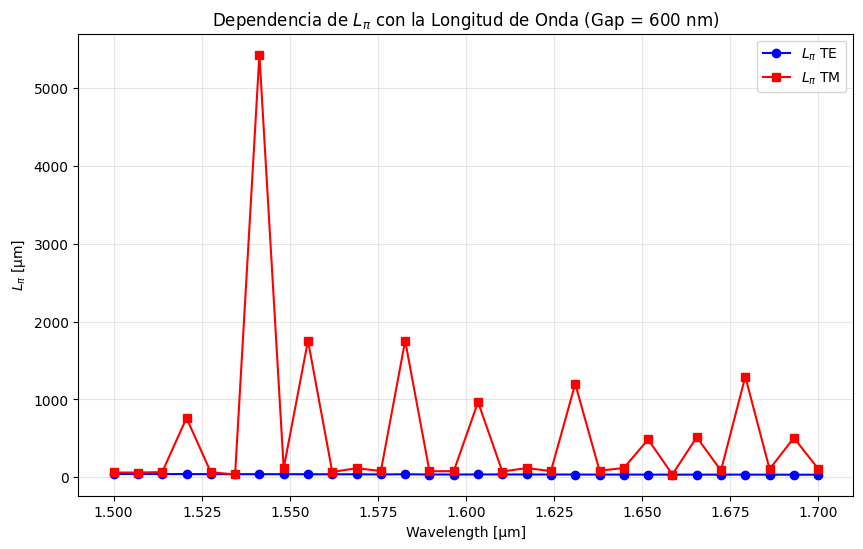

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición del rango de wavelength (1.5 a 1.7 con 30 pasos)
wavelengths = np.linspace(1.5, 1.7, 30)
res_L_pi_TE = []
res_L_pi_TM = []

print("Iniciando barrido de wavelength...")

for w in wavelengths:
    # Actualizamos el objeto Coupler con la wavelength actual
    deep_dcoupler_cs = gt.modes.WaveguideCoupler(
        wavelength=w, 
        core_width=(1.0, 1.0), 
        gap=600 * nm,
        slab_thickness=150 * nm, 
        core_material='sin', 
        clad_material='sio2', 
        core_thickness=300 * nm, 
        num_modes=4, 
        cache_path='.cache/', 
        precision='double',
        max_grid_scaling=1.5, 
        grid_resolution=20 
    )

    # Obtenemos los índices efectivos
    # Acceder a .n_eff suele disparar el cálculo en el motor EME/Solver
    deep_neff = deep_dcoupler_cs.n_eff
    
    # Calculamos L_pi usando la wavelength de la iteración 'w'
    # Usamos np.abs para evitar valores negativos por el orden de los modos
    L_pi_TE_val = 0.5 * w / np.abs(deep_neff[0].real - deep_neff[1].real)
    L_pi_TM_val = 0.5 * w / np.abs(deep_neff[2].real - deep_neff[3].real)
    
    # Guardamos los resultados en las listas
    res_L_pi_TE.append(L_pi_TE_val)
    res_L_pi_TM.append(L_pi_TM_val)

# 2. Generación de la gráfica única
plt.figure(figsize=(10, 6))
plt.plot(wavelengths, res_L_pi_TE, 'o-', label='$L_{\pi}$ TE', color='blue')
plt.plot(wavelengths, res_L_pi_TM, 's-', label='$L_{\pi}$ TM', color='red')

plt.title('Dependencia de $L_{\pi}$ con la Longitud de Onda (Gap = 600 nm)')
plt.xlabel('Wavelength [µm]')
plt.ylabel('$L_{\pi}$ [µm]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### E3. MMI coupler wavelength dependence

<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_117594/2726612080.py:41: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(wavelengths, l_pi_te_list, 'o-', label='$L_\pi$ TE (Modos 0,1)', color='blue')
/tmp/ipykernel_117594/2726612080.py:42: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(wavelengths, l_pi_tm_list, 's-', label='$L_\pi$ TM (Modos 2,3)', color='red')
/tmp/ipykernel_117594/2726612080.py:44: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Barrido de $L_\pi$ en el cuerpo del MMI (Ancho = 6.6 µm)')
/tmp/ipykernel_117594/2726612080.py:46: SyntaxWarning: invalid escape sequence '\p'
  plt

Iniciando barrido del cuerpo del MMI...


22:56:27 CEST WARNING: Mode field at frequency index 0, mode index 9 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 11 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 12 does not  
              decay at the plane boundaries.                                    

...

23:24:34 CEST WARNING: Mode field at frequency index 0, mode index 8 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 9 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 11 does not  
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 13 does not  
              decay at the plane boundaries.                                    

2026-05-03 23:24:34.211 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_7a54b34d317d0af0.npz.


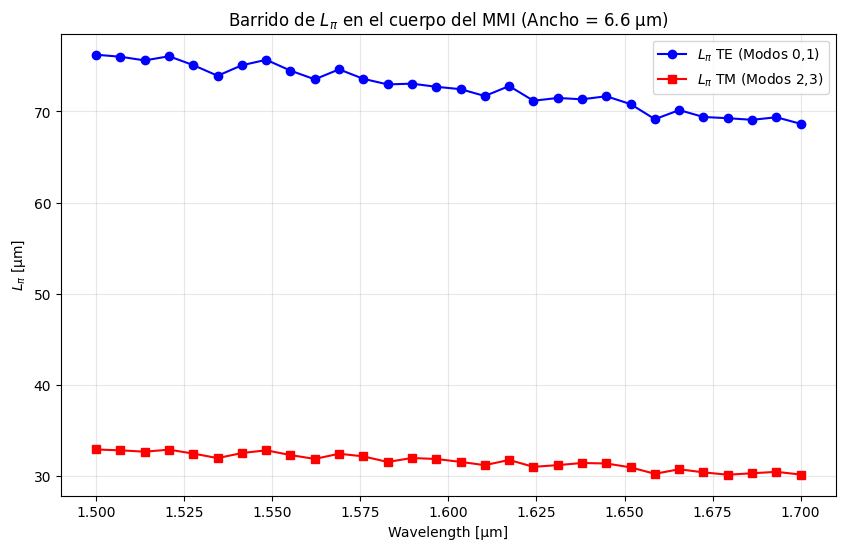

In [6]:

# 1. Definición del rango de wavelength (1.5 a 1.7 con 30 pasos)
wavelengths = np.linspace(1.5, 1.7, 30)
l_pi_te_list = []
l_pi_tm_list = []

print("Iniciando barrido del cuerpo del MMI...")

for lb in wavelengths:
    # Definimos el objeto para la longitud de onda actual
    mmi_body_waveguide = gt.modes.Waveguide(
        core_width=6.6, # mmi_body_w
        core_thickness=300 * nm,
        slab_thickness=150 * nm, # Deep-etched (sin slab)
        core_material='sin',
        clad_material='sio2',
        wavelength=lb,
        num_modes=15, 
        max_grid_scaling=1.5,
        grid_resolution=20,
        cache_path='.cache/',
        precision='double',
    )
    
    # Obtenemos los índices efectivos (n_eff)
    # n_eff[0] y n_eff[1] suelen ser TE0 y TE1 en guías anchas
    neffs = mmi_body_waveguide.n_eff
    
    # Cálculo de L_pi para TE (Modos 0 y 1)
    # L_pi = lambda / (2 * (n0 - n1))
    dn_te = np.abs(neffs[0].real - neffs[1].real)
    l_pi_te_list.append(0.5 * lb / dn_te)
    
    # Cálculo de L_pi para TM 
    # NOTA: En un MMI de 6.6um, los modos TM suelen empezar en índices más altos (ej. neffs[10])
    # Si tu manual indica usar [2] y [3], cámbialos aquí:
    dn_tm = np.abs(neffs[2].real - neffs[3].real) 
    l_pi_tm_list.append(0.5 * lb / dn_tm)

# 2. Generación de la gráfica
plt.figure(figsize=(10, 6))
plt.plot(wavelengths, l_pi_te_list, 'o-', label='$L_\pi$ TE (Modos 0,1)', color='blue')
plt.plot(wavelengths, l_pi_tm_list, 's-', label='$L_\pi$ TM (Modos 2,3)', color='red')

plt.title('Barrido de $L_\pi$ en el cuerpo del MMI (Ancho = 6.6 µm)')
plt.xlabel('Wavelength [µm]')
plt.ylabel('$L_\pi$ [µm]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### E4. MMI coupler body width dependence

<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:47: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:47: SyntaxWarning: invalid escape sequence '\p'
<>:49: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_117594/3038851073.py:44: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(widths, l_pi_te, 'o-', label='$L_\pi$ TE (Modos 0,1)', color='blue')
/tmp/ipykernel_117594/3038851073.py:45: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(widths, l_pi_tm, 's-', label='$L_\pi$ TM (Modos 2,3)', color='red')
/tmp/ipykernel_117594/3038851073.py:47: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Dependencia de $L_\pi$ con el ancho del cuerpo del MMI')
/tmp/ipykernel_117594/3038851073.py:49: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$L_\pi$ [µm]'

Iniciando barrido de ancho del cuerpo del MMI...


00:05:48 CEST WARNING: Mode field at frequency index 0, mode index 8 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 9 does not   
              decay at the plane boundaries.                                    

              WARNING: Mode field at frequency index 0, mode index 11 does not  
              decay at the plane boundaries.                                    

...

00:14:00 CEST WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

2026-05-04 00:14:00.693 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_4e080f8573a04258.npz.


/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/llopi/cifoin-lab2/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

00:15:27 CEST WARNING: Mode field at frequency index 0, mode index 14 does not  
              decay at the plane boundaries.                                    

2026-05-04 00:15:27.414 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_17e36e7035c1827e.npz.


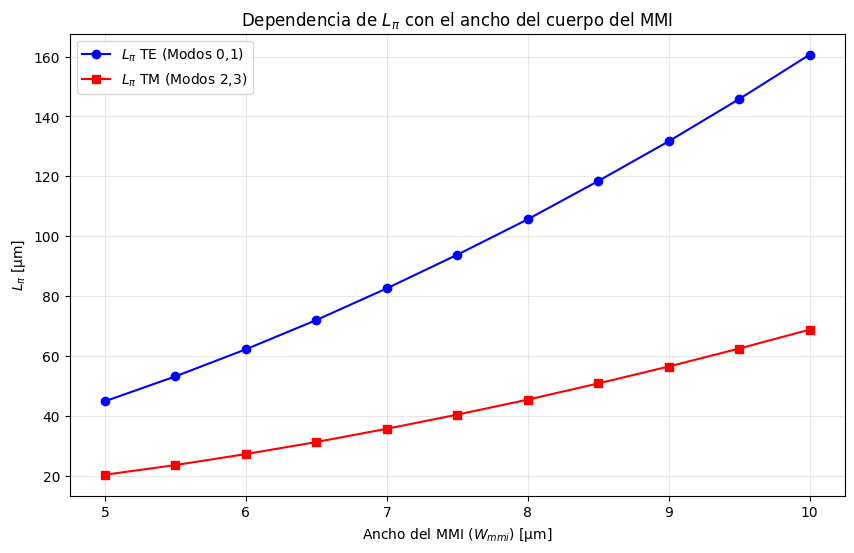

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros básicos y definición del barrido
lambda_c = 1.55
# Rango de 5 a 10 um con paso de 0.5 um
widths = np.arange(5, 10.5, 0.5) 

l_pi_te = []
l_pi_tm = []

print("Iniciando barrido de ancho del cuerpo del MMI...")

for w in widths:
    # 2. Configuración del cuerpo del MMI para cada ancho 'w'
    mmi_body_waveguide = gt.modes.Waveguide(
        core_width=w, # Se actualiza el ancho en cada iteración
        core_thickness=300 * nm, 
        slab_thickness=150 * nm, # Grabado profundo (deep-etched)
        core_material='sin', 
        clad_material='sio2', 
        wavelength=lambda_c, 
        num_modes=15, # Necesario para encontrar modos de orden superior
        max_grid_scaling=1.5,
        grid_resolution=20,
        cache_path='.cache/',
        precision='double',
    )
    
    # 3. Obtención de índices efectivos (neff)
    neffs = mmi_body_waveguide.n_eff
    
    # Cálculo de L_pi para TE (asumiendo modos 0 y 1)
    # Fórmula: L_pi = lambda / (2 * (n0 - n1))
    dn_te = np.abs(neffs[0].real - neffs[1].real)
    l_pi_te.append(0.5 * lambda_c / dn_te)
    
    # Cálculo de L_pi para TM (asumiendo los siguientes modos disponibles)
    dn_tm = np.abs(neffs[2].real - neffs[3].real)
    l_pi_tm.append(0.5 * lambda_c / dn_tm)

# 4. Generación de la gráfica (STUDENT plot)
plt.figure(figsize=(10, 6))
plt.plot(widths, l_pi_te, 'o-', label='$L_\pi$ TE (Modos 0,1)', color='blue')
plt.plot(widths, l_pi_tm, 's-', label='$L_\pi$ TM (Modos 2,3)', color='red')

plt.title('Dependencia de $L_\pi$ con el ancho del cuerpo del MMI')
plt.xlabel('Ancho del MMI ($W_{mmi}$) [µm]')
plt.ylabel('$L_\pi$ [µm]')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Grading 
- LO1 - 0.5 Point
- LO2 - 1 Point
- LO3 - 1 Point
- LO4 - 1 Point
- LO5 - 0.5 Point
- LO6 - 1 Point
- LO7 - 2 Points
- E1-E4 - Up to 3 Points